<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 152.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 167.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 129.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 144.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 151.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




In [3]:
# For scatterplot both variables must be nummerical
# Since Age is categorical in the Stack Overflow survey and JobSatPoints_6 is numeric, we should convert the age ranges to representative numeric values before creating the scatter plot.

# Let's check the columns
df[["Age", "JobSatPoints_6"]].head()

,Age,JobSatPoints_6
0,Under 18 years old,NaN
1,35-44 years old,0.0
2,45-54 years old,NaN
3,18-24 years old,NaN
4,18-24 years old,NaN


In [4]:
# Now let's convert Age in numerical values creating a new column on the df
age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65
}

df["AgeNumeric"] = df["Age"].map(age_mapping)

In [5]:
# Let's check the columns again
df[["Age", "AgeNumeric", "JobSatPoints_6"]].head()

,Age,AgeNumeric,JobSatPoints_6
0,Under 18 years old,17.0,NaN
1,35-44 years old,39.5,0.0
2,45-54 years old,49.5,NaN
3,18-24 years old,21.0,NaN
4,18-24 years old,21.0,NaN


In [6]:
# Now let's prepare the dataframe for the scatter plot removing missing values
scatter_df = df.dropna(
    subset=["AgeNumeric", "JobSatPoints_6"]
)

scatter_df[["AgeNumeric", "JobSatPoints_6"]].describe()

,AgeNumeric,JobSatPoints_6
count,29399.000000,29399.000000
mean,34.146434,24.364134
std,9.635772,27.100750
min,17.000000,0.000000
25%,29.500000,0.000000
50%,29.500000,20.000000
75%,39.500000,30.000000
max,65.000000,100.000000


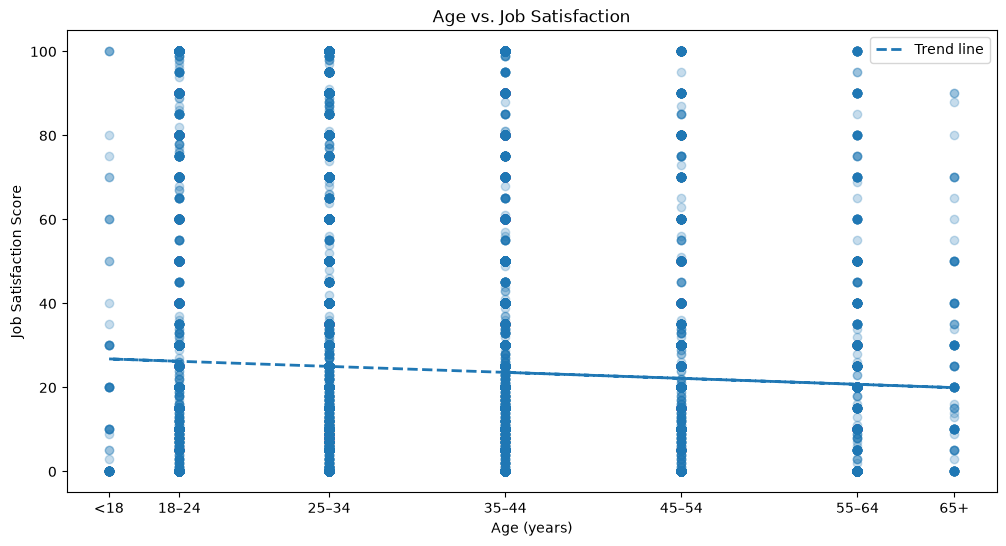

In [7]:
# Visualing the relationship between both variables
import numpy as np

x = scatter_df["AgeNumeric"]
y = scatter_df["JobSatPoints_6"]

slope, intercept = np.polyfit(x, y, 1)

plt.figure(figsize=(12, 6))

plt.scatter(
    x,
    y,
    alpha=0.25
)

plt.plot(
    x,
    slope * x + intercept,
    linestyle="--",
    linewidth=2,
    label="Trend line"
)

plt.title("Age vs. Job Satisfaction")
plt.xlabel("Age (years)")
plt.ylabel("Job Satisfaction Score")

plt.xticks(
    [17, 21, 29.5, 39.5, 49.5, 59.5, 65],
    ["<18", "18–24", "25–34", "35–44", "45–54", "55–64", "65+"]
)

plt.legend()

plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


In [10]:
# Let's check the columns values
df[["ConvertedCompYearly", "JobSatPoints_6"]].value_counts()

ConvertedCompYearly  JobSatPoints_6
64444.0              0.0               50
53703.0              0.0               42
                     20.0              38
64444.0              20.0              36
75184.0              0.0               36
                                       ..
23256.0              40.0               1
15637.0              20.0               1
9711.0               80.0               1
44640.0              0.0                1
222834.0             25.0               1
Name: count, Length: 9871, dtype: int64

In [12]:
# Both columns are numerical that's awesome
# Let's create a bew dataframe with the required columns
scatter_df = df[
    ["ConvertedCompYearly", "JobSatPoints_6"]
].copy()

# And remove missing values
scatter_df = scatter_df.dropna(
    subset=["ConvertedCompYearly", "JobSatPoints_6"]
)

# Checking the data
scatter_df.describe()

,ConvertedCompYearly,JobSatPoints_6
count,1.618500e+04,16185.000000
mean,8.577514e+04,25.105968
std,1.717094e+05,26.503119
min,1.000000e+00,0.000000
25%,3.356800e+04,5.000000
50%,6.573300e+04,20.000000
75%,1.080020e+05,30.000000
max,1.381802e+07,100.000000


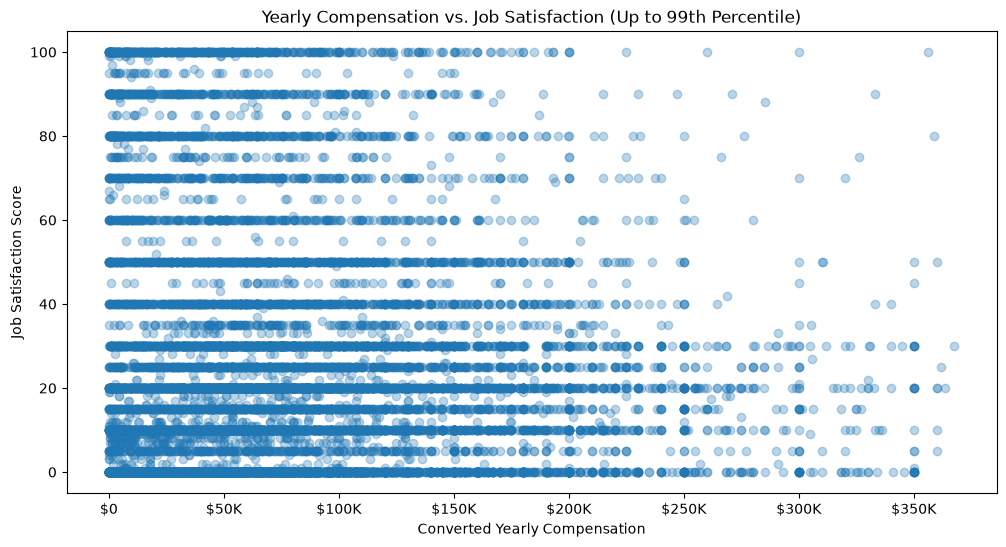

In [14]:
# Now Let's visualize the scatterplot and check the relationship
from matplotlib.ticker import FuncFormatter
upper_limit = scatter_df["ConvertedCompYearly"].quantile(0.99)

def currency_formatter(x, pos):
    if x >= 1_000_000:
        return f"${x/1_000_000:.0f}M"
    elif x >= 1_000:
        return f"${x/1_000:.0f}K"
    else:
        return f"${x:.0f}"

plt.figure(figsize=(12, 6))

plt.scatter(
    scatter_df.loc[
        scatter_df["ConvertedCompYearly"] <= upper_limit,
        "ConvertedCompYearly"
    ],
    scatter_df.loc[
        scatter_df["ConvertedCompYearly"] <= upper_limit,
        "JobSatPoints_6"
    ],
    alpha=0.3
)

plt.title(
    "Yearly Compensation vs. Job Satisfaction "
    "(Up to 99th Percentile)"
)

plt.xlabel("Converted Yearly Compensation")
plt.ylabel("Job Satisfaction Score")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


In [16]:
# Let's create a dataframe with required data and calculate the regression line using numpy polyfit()
import numpy as np

age_jobsat = df[
    ["AgeNumeric", "JobSatPoints_6"]
].dropna()

x = age_jobsat["AgeNumeric"]
y = age_jobsat["JobSatPoints_6"]

slope, intercept = np.polyfit(x, y, 1)

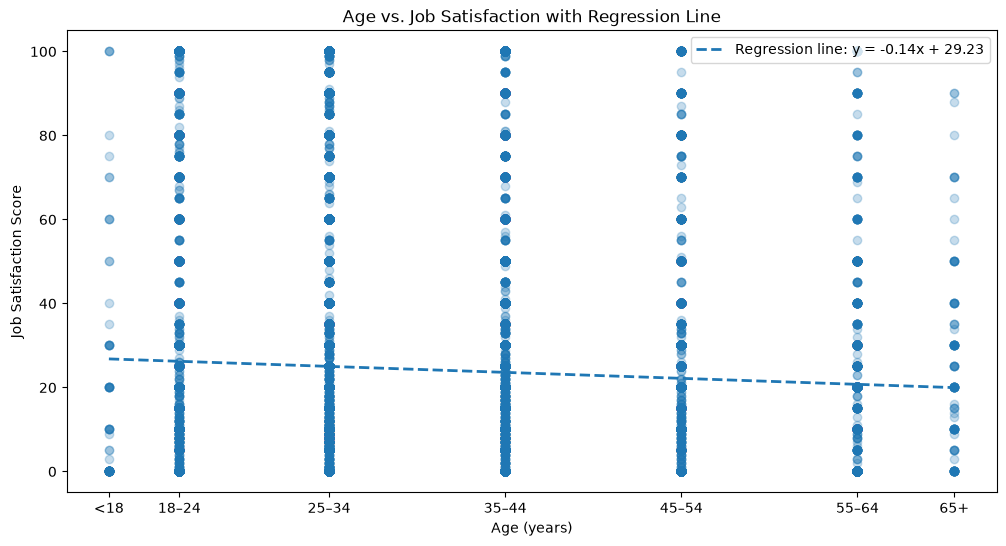

In [17]:
# Creating a scatterplot + regression line
plt.figure(figsize=(12, 6))

# Scatter plot
plt.scatter(
    x,
    y,
    alpha=0.25
)

# Create regression line
x_line = np.linspace(
    x.min(),
    x.max(),
    100
)

y_line = slope * x_line + intercept

plt.plot(
    x_line,
    y_line,
    linestyle="--",
    linewidth=2,
    label=f"Regression line: y = {slope:.2f}x + {intercept:.2f}"
)

plt.title("Age vs. Job Satisfaction with Regression Line")
plt.xlabel("Age (years)")
plt.ylabel("Job Satisfaction Score")

plt.xticks(
    [17, 21, 29.5, 39.5, 49.5, 59.5, 65],
    ["<18", "18–24", "25–34", "35–44", "45–54", "55–64", "65+"]
)

plt.legend()

plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


In [26]:
# Age was alredy converted into numerical values in our main dataframe df on "AgeNumeric" column
# Let's check YerasCodePro column
df["YearsCodePro"].value_counts()

YearsCodePro
2                     4168
3                     4093
5                     3526
10                    3251
4                     3215
Less than 1 year      2856
6                     2843
1                     2639
8                     2549
7                     2517
12                    1777
15                    1635
20                    1549
9                     1493
11                    1312
13                    1127
14                    1082
25                     998
16                     946
18                     867
17                     814
30                     689
24                     632
19                     516
22                     492
23                     448
26                     426
27                     380
21                     380
28                     342
35                     285
29                     196
32                     194
40                     194
34                     169
38                     134
33             

In [27]:
# Let's convert YearsCodePro into numerical values as we've done with Age
years_mapping = {
    "Less than 1 year": 0.5,
    "More than 50 years": 51
}

df["YearsCodeProNumeric"] = df["YearsCodePro"].replace(
    years_mapping
)

df["YearsCodeProNumeric"] = pd.to_numeric(
    df["YearsCodeProNumeric"],
    errors="coerce"
)

In [28]:
# Now let's create a clean dataframe with both columns for our visualization
scatter_df = df[
    ["AgeNumeric", "YearsCodeProNumeric"]
].dropna()

scatter_df.describe()

,AgeNumeric,YearsCodeProNumeric
count,51487.000000,51487.000000
mean,34.109960,10.193729
std,10.440556,9.055464
min,17.000000,0.500000
25%,29.500000,3.000000
50%,29.500000,7.000000
75%,39.500000,15.000000
max,65.000000,51.000000


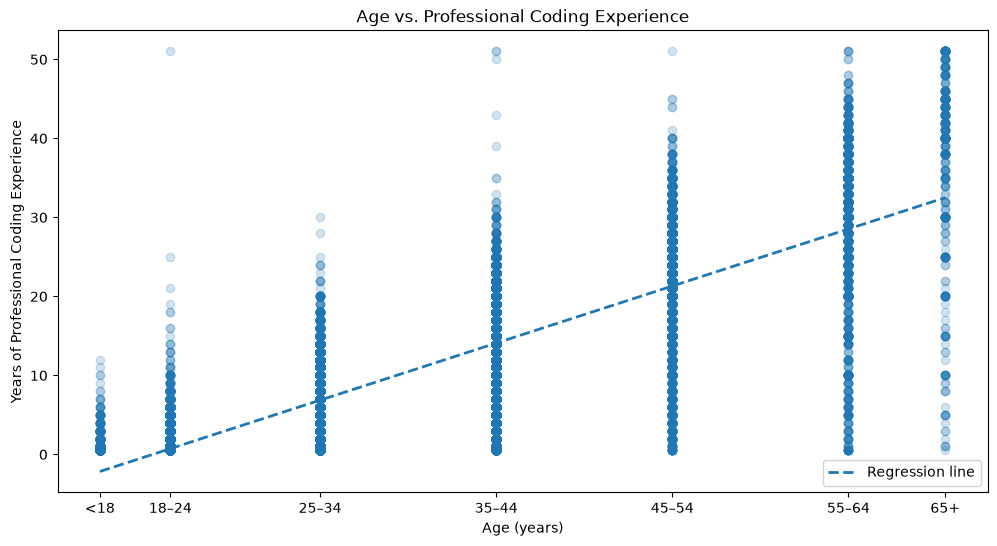

In [29]:
# Let's generate our scatterplot
x = scatter_df["AgeNumeric"]
y = scatter_df["YearsCodeProNumeric"]

slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

plt.figure(figsize=(12, 6))

plt.scatter(
    x,
    y,
    alpha=0.2
)

plt.plot(
    x_line,
    y_line,
    linestyle="--",
    linewidth=2,
    label="Regression line"
)

plt.title("Age vs. Professional Coding Experience")
plt.xlabel("Age (years)")
plt.ylabel("Years of Professional Coding Experience")

plt.xticks(
    [17, 21, 29.5, 39.5, 49.5, 59.5, 65],
    ["<18", "18–24", "25–34", "35–44", "45–54", "55–64", "65+"]
)

plt.legend()

plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


In [30]:
# Let's create a new dataframe with required columns
bubble_df = df[
    ["AgeNumeric", "ConvertedCompYearly", "JobSatPoints_6"]
].copy()

In [31]:
# And make sure ConvertedCompYearly and JobSatPoints_6 are numerical values
bubble_df["ConvertedCompYearly"] = pd.to_numeric(
    bubble_df["ConvertedCompYearly"],
    errors="coerce"
)

bubble_df["JobSatPoints_6"] = pd.to_numeric(
    bubble_df["JobSatPoints_6"],
    errors="coerce"
)

In [32]:
# Remove missing values
bubble_df = bubble_df.dropna(
    subset=[
        "AgeNumeric",
        "ConvertedCompYearly",
        "JobSatPoints_6"
    ]
)

In [33]:
# Let'create a upperlimit for better visualization was there'are extremelly high compensation values
upper_limit = bubble_df["ConvertedCompYearly"].quantile(0.95)

bubble_plot = bubble_df[
    bubble_df["ConvertedCompYearly"] <= upper_limit
].copy()

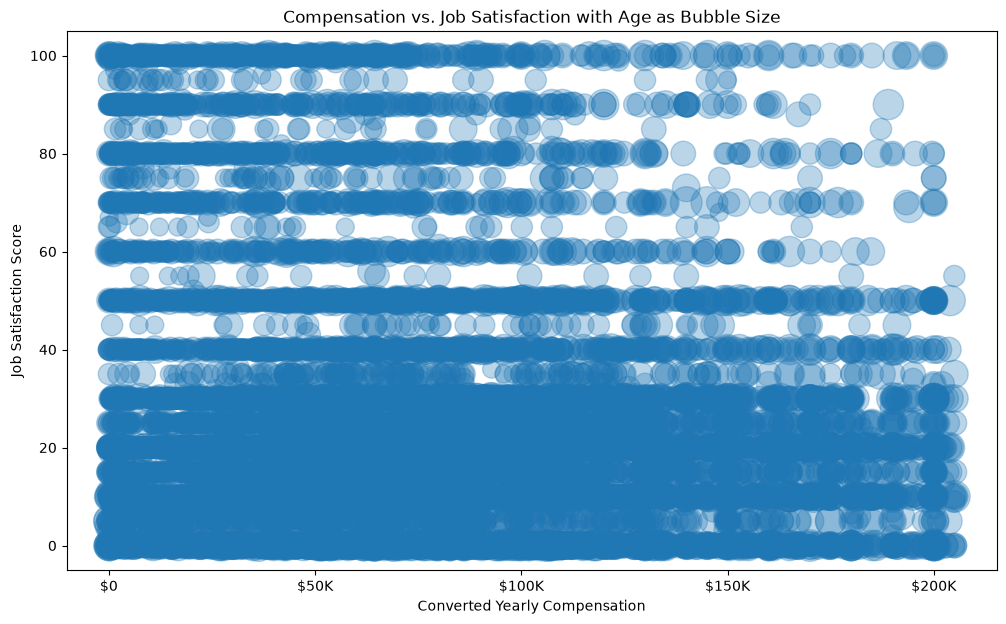

In [34]:
# Visualizing our Bubleplot
plt.figure(figsize=(12, 7))

plt.scatter(
    bubble_plot["ConvertedCompYearly"],
    bubble_plot["JobSatPoints_6"],
    s=bubble_plot["AgeNumeric"] * 8,
    alpha=0.3
)

plt.title(
    "Compensation vs. Job Satisfaction "
    "with Age as Bubble Size"
)

plt.xlabel("Converted Yearly Compensation")
plt.ylabel("Job Satisfaction Score")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


In [35]:
# Let's create a new dataframe with the required columns and remove missing values
language_df = df[
    ["LanguageHaveWorkedWith", "JobSatPoints_6"]
].copy()

language_df["JobSatPoints_6"] = pd.to_numeric(
    language_df["JobSatPoints_6"],
    errors="coerce"
)

language_df = language_df.dropna(
    subset=["LanguageHaveWorkedWith", "JobSatPoints_6"]
)

In [36]:
# Program Languages are separeted by ";" as we've realized in previous assessments
# Let's split them in individuals records
language_df["Language"] = (
    language_df["LanguageHaveWorkedWith"]
    .str.split(";")
)

language_df = language_df.explode("Language")

language_df["Language"] = (
    language_df["Language"]
    .str.strip()
)

In [37]:
# Now let's calculate language popularity and average satisfaction
language_stats = (
    language_df
    .groupby("Language")
    .agg(
        Respondents=("Language", "size"),
        AvgJobSatisfaction=("JobSatPoints_6", "mean")
    )
    .reset_index()
)

In [38]:
# Let's check the results
language_stats.sort_values(
    "Respondents",
    ascending=False
).head(10)

,Language,Respondents,AvgJobSatisfaction
22,JavaScript,18673,24.932811
40,SQL,16233,24.889480
19,HTML/CSS,15537,24.983012
36,Python,14450,22.974692
44,TypeScript,12671,25.327332
3,Bash/Shell (all shells),10795,23.237911
21,Java,8805,25.752243
5,C#,8627,24.760905
6,C++,5867,23.921340
32,PHP,5325,25.772770


In [39]:
# For a better visualization let's select the top 10 languages
top_languages = (
    language_stats
    .nlargest(10, "Respondents")
)

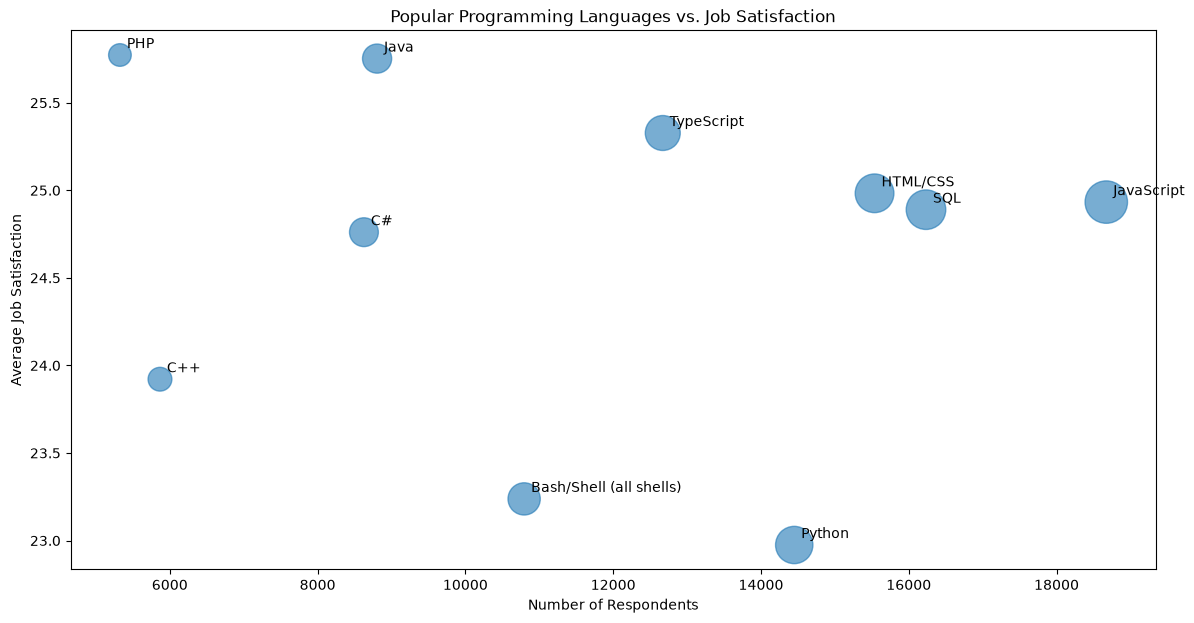

In [40]:
# And visualize our scatterplot
plt.figure(figsize=(14, 7))

plt.scatter(
    top_languages["Respondents"],
    top_languages["AvgJobSatisfaction"],
    s=top_languages["Respondents"] / 20,
    alpha=0.6
)

for _, row in top_languages.iterrows():
    plt.annotate(
        row["Language"],
        (
            row["Respondents"],
            row["AvgJobSatisfaction"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title(
    "Popular Programming Languages vs. Job Satisfaction"
)

plt.xlabel("Number of Respondents")
plt.ylabel("Average Job Satisfaction")

plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


In [45]:
# Let's check the columns
df[["ConvertedCompYearly", "JobSatPoints_6", "Employment"]].value_counts()

ConvertedCompYearly  JobSatPoints_6  Employment                                                              
64444.0              0.0             Employed, full-time                                                         39
53703.0              0.0             Employed, full-time                                                         32
48333.0              0.0             Employed, full-time                                                         30
200000.0             0.0             Employed, full-time                                                         29
85925.0              20.0            Employed, full-time                                                         28
                                                                                                                 ..
15637.0              20.0            Student, full-time;Independent contractor, freelancer, or self-employed      1
9711.0               80.0            Employed, full-time                      

In [46]:
# Let's prepare a new dataframe with the required data and remove missing values
employment_df = df[
    ["ConvertedCompYearly", "JobSatPoints_6", "Employment"]
].copy()

employment_df["ConvertedCompYearly"] = pd.to_numeric(
    employment_df["ConvertedCompYearly"],
    errors="coerce"
)

employment_df["JobSatPoints_6"] = pd.to_numeric(
    employment_df["JobSatPoints_6"],
    errors="coerce"
)

employment_df = employment_df.dropna(
    subset=[
        "ConvertedCompYearly",
        "JobSatPoints_6",
        "Employment"
    ]
)

In [47]:
# Employment is a multi-select field, so a respondent can have more than one employment type
# Let's separate them
employment_df["EmploymentType"] = (
    employment_df["Employment"]
    .str.split(";")
)

employment_df = employment_df.explode(
    "EmploymentType"
)

employment_df["EmploymentType"] = (
    employment_df["EmploymentType"]
    .str.strip()
)

In [48]:
# Now let's check the top 5 employment types for a better visualization
top_employment = (
    employment_df["EmploymentType"]
    .value_counts()
    .head(5)
)

top_employment

EmploymentType
Employed, full-time                                     14698
Independent contractor, freelancer, or self-employed     2314
Employed, part-time                                       941
Student, part-time                                        527
Student, full-time                                        502
Name: count, dtype: int64

In [49]:
# Limit extreme compensation values
upper_limit = employment_df[
    "ConvertedCompYearly"
].quantile(0.99)

employment_plot = employment_df[
    employment_df["ConvertedCompYearly"] <= upper_limit
].copy()

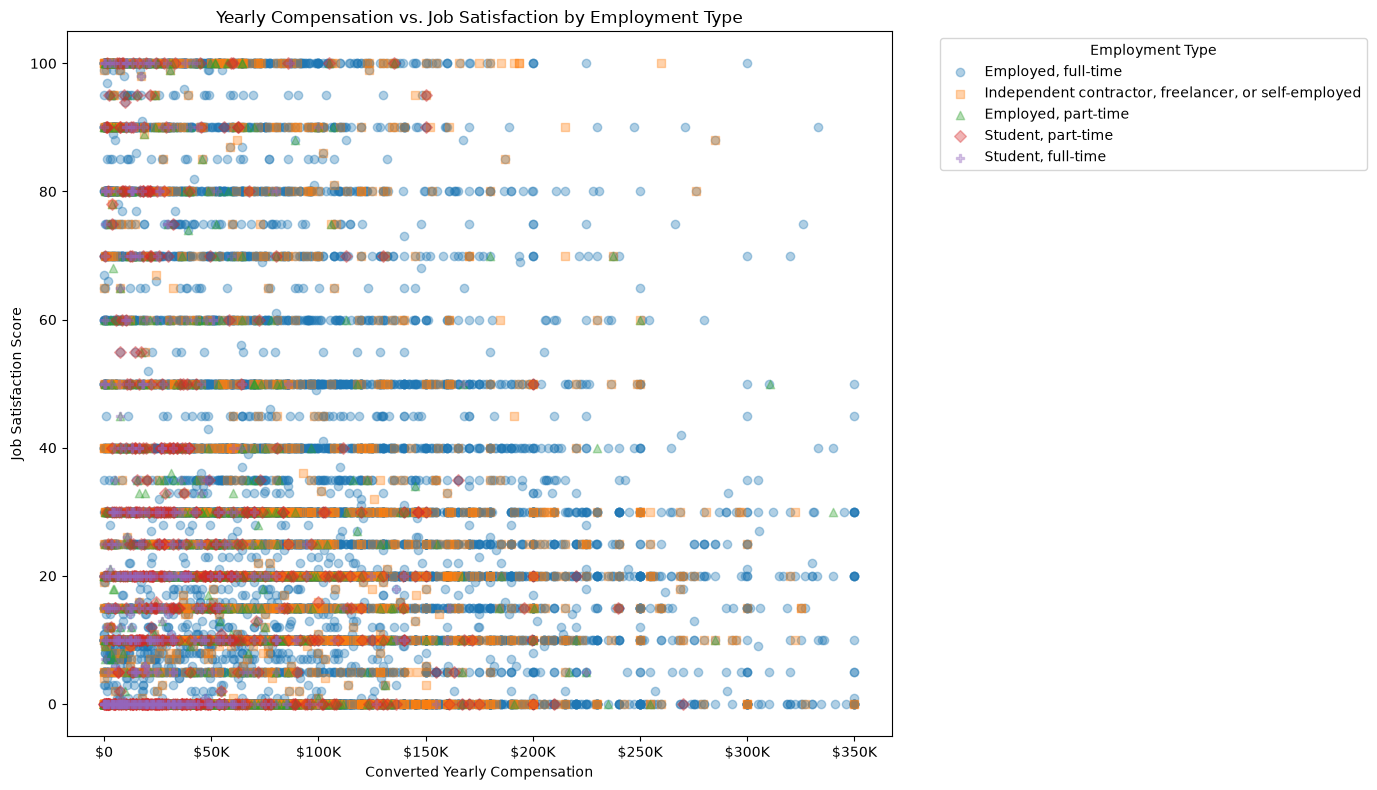

In [50]:
# Creating our scatterplot
employment_types = top_employment.index.tolist()

markers = ["o", "s", "^", "D", "P"]

plt.figure(figsize=(14, 8))

for employment_type, marker in zip(
    employment_types,
    markers
):
    group = employment_plot[
        employment_plot["EmploymentType"] == employment_type
    ]

    plt.scatter(
        group["ConvertedCompYearly"],
        group["JobSatPoints_6"],
        marker=marker,
        alpha=0.35,
        label=employment_type
    )

plt.title(
    "Yearly Compensation vs. Job Satisfaction "
    "by Employment Type"
)

plt.xlabel("Converted Yearly Compensation")
plt.ylabel("Job Satisfaction Score")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(currency_formatter)
)

plt.legend(
    title="Employment Type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


In [51]:
# Let's check the columns
df[["Age", "AgeNumeric", "YearsCodeProNumeric", "Country"]]

,Age,AgeNumeric,YearsCodeProNumeric,Country
0,Under 18 years old,17.0,NaN,United States of America
1,35-44 years old,39.5,17.0,United Kingdom of Great Britain and Northern I...
2,45-54 years old,49.5,27.0,United Kingdom of Great Britain and Northern I...
3,18-24 years old,21.0,NaN,Canada
4,18-24 years old,21.0,NaN,Norway
...,...,...,...,...
65432,18-24 years old,21.0,3.0,NaN
65433,25-34 years old,29.5,NaN,NaN
65434,25-34 years old,29.5,5.0,NaN
65435,18-24 years old,21.0,2.0,Germany


In [52]:
# Let's create a clean dataframe with the required columns for the analysis
experience_df = df[
    [
        "Age",
        "AgeNumeric",
        "YearsCodeProNumeric",
        "Country"
    ]
].dropna()

In [54]:
# Find the top 5 contries for a better visualization
top_countries = (
    experience_df["Country"]
    .value_counts()
    .head(5)
)

top_countries

Country
United States of America                                9528
Germany                                                 4309
India                                                   3309
United Kingdom of Great Britain and Northern Ireland    2778
Ukraine                                                 2410
Name: count, dtype: int64

In [60]:
# Now let's filter our dataframe based on the top 5 countries
experience_df = experience_df[
    experience_df["Country"].isin(
        top_countries.index
    )
]

In [61]:
# Let's check our dataframe again
experience_df

,Age,AgeNumeric,YearsCodeProNumeric,Country
1,35-44 years old,39.5,17.0,United Kingdom of Great Britain and Northern I...
2,45-54 years old,49.5,27.0,United Kingdom of Great Britain and Northern I...
6,35-44 years old,39.5,7.0,United States of America
12,35-44 years old,39.5,12.0,United States of America
17,18-24 years old,21.0,3.0,India
...,...,...,...,...
65339,18-24 years old,21.0,2.0,India
65353,25-34 years old,29.5,11.0,United Kingdom of Great Britain and Northern I...
65371,25-34 years old,29.5,2.0,Germany
65428,25-34 years old,29.5,7.0,India


In [63]:
# For a better vizualization let's update the Age categories for a short representation
age_mapping = {
    "Under 18 years old": "<18",
    "18-24 years old": "18-24",
    "25-34 years old": "25-34",
    "35-44 years old": "35-44",
    "45-54 years old": "45-54",
    "55-64 years old": "55-64",
    "65 years or older": "65+"
}

experience_df["Age"] = experience_df["Age"].replace(age_mapping)

In [71]:
# Let's check the unique colum values
experience_df[["Age","AgeNumeric"]]

,Age,AgeNumeric
1,35-44,39.5
2,45-54,49.5
6,35-44,39.5
12,35-44,39.5
17,18-24,21.0
...,...,...
65339,18-24,21.0
65353,25-34,29.5
65371,25-34,29.5
65428,25-34,29.5


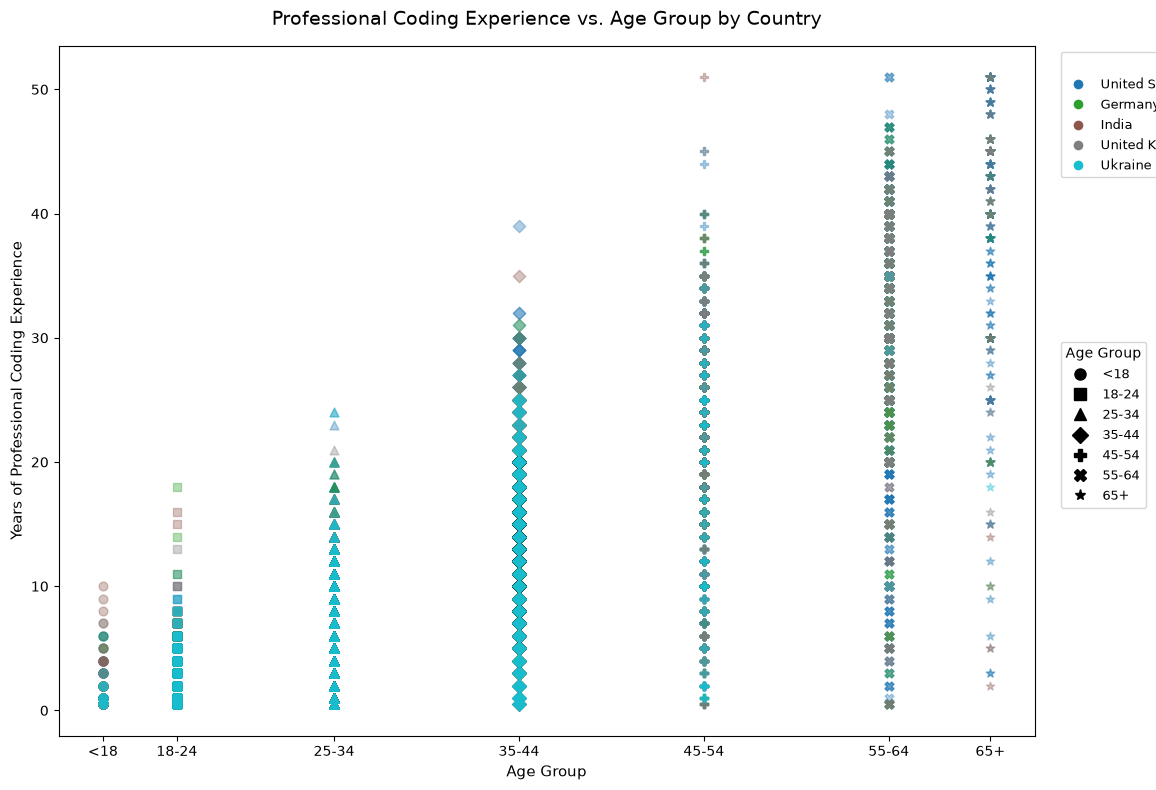

In [77]:
# And visualize our scatterplot
# Visualize the scatterplot
from matplotlib.lines import Line2D

plt.figure(figsize=(15, 8))

countries = top_countries.index.tolist()

age_groups = [
    "<18",
    "18-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65+"
]

markers = [
    "o",
    "s",
    "^",
    "D",
    "P",
    "X",
    "*"
]

# Create color mapping for countries
colors = plt.cm.tab10(
    np.linspace(0, 1, len(countries))
)

country_colors = dict(
    zip(countries, colors)
)

# Create marker mapping for age groups
age_markers = dict(
    zip(age_groups, markers)
)

# Plot each country and age group
for country in countries:

    for age_group in age_groups:

        group = experience_df[
            (experience_df["Country"] == country) &
            (experience_df["Age"] == age_group)
        ]

        if not group.empty:

            plt.scatter(
                group["AgeNumeric"],
                group["YearsCodeProNumeric"],
                color=country_colors[country],
                marker=age_markers[age_group],
                alpha=0.35,
                s=40
            )


# --------------------------------------------------
# Titles and axis labels
# --------------------------------------------------

plt.title(
    "Professional Coding Experience vs. Age Group by Country",
    fontsize=14,
    pad=15
)

plt.xlabel(
    "Age Group",
    fontsize=11
)

plt.ylabel(
    "Years of Professional Coding Experience",
    fontsize=11
)


# --------------------------------------------------
# X-axis labels
# --------------------------------------------------

plt.xticks(
    [17, 21, 29.5, 39.5, 49.5, 59.5, 65],
    age_groups
)


# --------------------------------------------------
# Country legend
# --------------------------------------------------

country_legend = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=country_colors[country],
        markersize=8,
        label=country
    )
    for country in countries
]


# --------------------------------------------------
# Age group legend
# --------------------------------------------------

age_legend = [
    Line2D(
        [0], [0],
        marker=marker,
        color="black",
        linestyle="None",
        markersize=8,
        label=age
    )
    for age, marker in zip(age_groups, markers)
]


# --------------------------------------------------
# Add Country legend
# --------------------------------------------------

legend1 = plt.legend(
    handles=country_legend,
    title="Country",
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    fontsize=9,
    title_fontsize=10,
    frameon=True
)

plt.gca().add_artist(legend1)


# --------------------------------------------------
# Add Age Group legend
# --------------------------------------------------

plt.legend(
    handles=age_legend,
    title="Age Group",
    loc="upper left",
    bbox_to_anchor=(1.02, 0.58),
    fontsize=9,
    title_fontsize=10,
    frameon=True
)


# Leave enough space for legends
plt.tight_layout(rect=[0, 0, 0.78, 1])

plt.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
